# Customer Retention & Churn Analysis
### Telco Customer Churn Dataset | Data Science & Analytics Internship Task 2
**Tools:** Python, Pandas, Matplotlib, Seaborn, Power BI  
**Dataset:** Telco Customer Churn  
**Author:** Ngcebo Enock Mntungwa  
**Date:** June 2026

## 0. Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Data Loading
Loading the Telco Customer Churn dataset from the data folder.

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Data Exploration
Initial exploration to understand the dataset structure, size, and data quality.

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [8]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].unique()[:10])

object
['29.85' '1889.5' '108.15' '1840.75' '151.65' '820.5' '1949.4' '301.9'
 '3046.05' '3487.95']


## 3. Data Cleaning

In [9]:
### 3.1 Fix TotalCharges column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df['TotalCharges'].dtype)

float64


In [10]:
print(df['TotalCharges'].isnull().sum())

11


In [11]:
### 3.2 Drop null TotalCharges rows
df = df.dropna(subset=['TotalCharges'])
print(f"Remaining rows: {df.shape[0]}")

Remaining rows: 7032


In [12]:
### 3.3 Check for duplicates
print(df.duplicated().sum())

0


In [13]:
### 3.4 Convert Churn to numeric
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [14]:
### 3.5 Create Tenure Groups
def tenure_group(tenure):
    if tenure <= 12:
        return '0-12 Months'
    elif tenure <= 24:
        return '13-24 Months'
    elif tenure <= 48:
        return '25-48 Months'
    elif tenure <= 60:
        return '49-60 Months'
    else:
        return '61+ Months'

df['TenureGroup'] = df['tenure'].apply(tenure_group)
print(df['TenureGroup'].value_counts())

TenureGroup
0-12 Months     2175
25-48 Months    1594
61+ Months      1407
13-24 Months    1024
49-60 Months     832
Name: count, dtype: int64


In [15]:
### 3.6 Check SeniorCitizen column
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
0    5890
1    1142
Name: count, dtype: int64


In [16]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print(df['SeniorCitizen'].value_counts())

SeniorCitizen
No     5890
Yes    1142
Name: count, dtype: int64


## 4. Feature Understanding
Understanding what each column represents in the dataset.

In [18]:
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 
                    'PhoneService', 'MultipleLines', 'InternetService', 
                    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                    'TechSupport', 'StreamingTV', 'StreamingMovies',
                    'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']

for col in categorical_cols:
    print(f"\n{col} ({df[col].nunique()} unique values):")
    print(df[col].unique())


gender (2 unique values):
['Female' 'Male']

SeniorCitizen (2 unique values):
['No' 'Yes']

Partner (2 unique values):
['Yes' 'No']

Dependents (2 unique values):
['No' 'Yes']

PhoneService (2 unique values):
['No' 'Yes']

MultipleLines (3 unique values):
['No phone service' 'No' 'Yes']

InternetService (3 unique values):
['DSL' 'Fiber optic' 'No']

OnlineSecurity (3 unique values):
['No' 'Yes' 'No internet service']

OnlineBackup (3 unique values):
['Yes' 'No' 'No internet service']

DeviceProtection (3 unique values):
['No' 'Yes' 'No internet service']

TechSupport (3 unique values):
['No' 'Yes' 'No internet service']

StreamingTV (3 unique values):
['No' 'Yes' 'No internet service']

StreamingMovies (3 unique values):
['No' 'Yes' 'No internet service']

Contract (3 unique values):
['Month-to-month' 'One year' 'Two year']

PaperlessBilling (2 unique values):
['Yes' 'No']

PaymentMethod (4 unique values):
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (a

## 5. KPI Calculations
Calculating the core business metrics for the retention analysis.

In [19]:
### 5.1 Churn Rate & Retention Rate
churn_rate = df['Churn'].mean() * 100
retention_rate = 100 - churn_rate
print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {retention_rate:.2f}%")

Churn Rate: 26.58%
Retention Rate: 73.42%


In [20]:
### 5.2 Average Customer Tenure
avg_tenure = df['tenure'].mean()
churned_tenure = df[df['Churn']==1]['tenure'].mean()
retained_tenure = df[df['Churn']==0]['tenure'].mean()
print(f"Average Tenure (All): {avg_tenure:.1f} months")
print(f"Average Tenure (Churned): {churned_tenure:.1f} months")
print(f"Average Tenure (Retained): {retained_tenure:.1f} months")

Average Tenure (All): 32.4 months
Average Tenure (Churned): 18.0 months
Average Tenure (Retained): 37.7 months


In [21]:
### 5.3 Monthly Charges
avg_monthly = df['MonthlyCharges'].mean()
churned_monthly = df[df['Churn']==1]['MonthlyCharges'].mean()
retained_monthly = df[df['Churn']==0]['MonthlyCharges'].mean()
print(f"Avg Monthly Charges (All): ${avg_monthly:.2f}")
print(f"Avg Monthly Charges (Churned): ${churned_monthly:.2f}")
print(f"Avg Monthly Charges (Retained): ${retained_monthly:.2f}")

Avg Monthly Charges (All): $64.80
Avg Monthly Charges (Churned): $74.44
Avg Monthly Charges (Retained): $61.31


## 6. Churn Analysis
Analyzing churn rates across different customer segments and service types.

In [23]:
### 6.1 Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
print(contract_churn.sort_values(ascending=False))

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn, dtype: float64


In [24]:
### 6.2 Churn by Internet Service
internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
print(internet_churn.sort_values(ascending=False))

InternetService
Fiber optic    41.892765
DSL            18.998344
No              7.434211
Name: Churn, dtype: float64


In [25]:
### 6.3 Churn by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn'].mean() * 100
print(payment_churn.sort_values(ascending=False))

PaymentMethod
Electronic check             45.285412
Mailed check                 19.201995
Bank transfer (automatic)    16.731518
Credit card (automatic)      15.253123
Name: Churn, dtype: float64


In [26]:
### 6.4 Churn by Senior Citizen
senior_churn = df.groupby('SeniorCitizen')['Churn'].mean() * 100
print(senior_churn.sort_values(ascending=False))

SeniorCitizen
Yes    41.681261
No     23.650255
Name: Churn, dtype: float64


In [27]:
### 6.5 Churn by Tenure Group
tenure_churn = df.groupby('TenureGroup')['Churn'].mean() * 100
print(tenure_churn.sort_values(ascending=False))

TenureGroup
0-12 Months     47.678161
13-24 Months    28.710938
25-48 Months    20.388959
49-60 Months    14.423077
61+ Months       6.609808
Name: Churn, dtype: float64


In [28]:
### 6.6 Churn by Gender
gender_churn = df.groupby('gender')['Churn'].mean() * 100
print(gender_churn.sort_values(ascending=False))

gender
Female    26.959518
Male      26.204565
Name: Churn, dtype: float64


In [30]:
### 6.7 Churn by Partner Status
partner_churn = df.groupby('Partner')['Churn'].mean() * 100
print(partner_churn.sort_values(ascending=False))

Partner
No     32.976092
Yes    19.717065
Name: Churn, dtype: float64


In [31]:
### 6.8 Churn by Dependents
dependents_churn = df.groupby('Dependents')['Churn'].mean() * 100
print(dependents_churn.sort_values(ascending=False))

Dependents
No     31.279140
Yes    15.531205
Name: Churn, dtype: float64


In [32]:
### 6.9 Churn by Online Security
security_churn = df.groupby('OnlineSecurity')['Churn'].mean() * 100
print(security_churn.sort_values(ascending=False))

OnlineSecurity
No                     41.778667
Yes                    14.640199
No internet service     7.434211
Name: Churn, dtype: float64


## 7. Cohort Analysis
Analyzing customer lifetime patterns and retention by tenure group.

In [33]:
### 7.1 Retention Rate by Tenure Group
tenure_retention = df.groupby('TenureGroup')['Churn'].agg(
    Total='count',
    Churned='sum'
)
tenure_retention['Retained'] = tenure_retention['Total'] - tenure_retention['Churned']
tenure_retention['Churn Rate'] = (tenure_retention['Churned'] / tenure_retention['Total'] * 100).round(2)
tenure_retention['Retention Rate'] = (100 - tenure_retention['Churn Rate']).round(2)
print(tenure_retention)

              Total  Churned  Retained  Churn Rate  Retention Rate
TenureGroup                                                       
0-12 Months    2175     1037      1138       47.68           52.32
13-24 Months   1024      294       730       28.71           71.29
25-48 Months   1594      325      1269       20.39           79.61
49-60 Months    832      120       712       14.42           85.58
61+ Months     1407       93      1314        6.61           93.39


In [34]:
### 7.2 Monthly Charges by Tenure Group
tenure_charges = df.groupby('TenureGroup')['MonthlyCharges'].mean().round(2)
print(tenure_charges.sort_values(ascending=False))

TenureGroup
61+ Months      75.95
49-60 Months    70.55
25-48 Months    65.93
13-24 Months    61.36
0-12 Months     56.17
Name: MonthlyCharges, dtype: float64


In [37]:
### 7.3 Churn by Contract Type and Tenure Group
contract_tenure = df.groupby(['Contract', 'TenureGroup'])['Churn'].mean() * 100
print(contract_tenure.round(2))

Contract        TenureGroup 
Month-to-month  0-12 Months     51.35
                13-24 Months    37.72
                25-48 Months    32.92
                49-60 Months    27.78
                61+ Months      22.22
One year        0-12 Months     10.57
                13-24 Months     8.12
                25-48 Months    10.62
                49-60 Months    13.71
                61+ Months      12.14
Two year        0-12 Months      0.00
                13-24 Months     0.00
                25-48 Months     2.19
                49-60 Months     3.97
                61+ Months       3.14
Name: Churn, dtype: float64


## 8. Visualizations

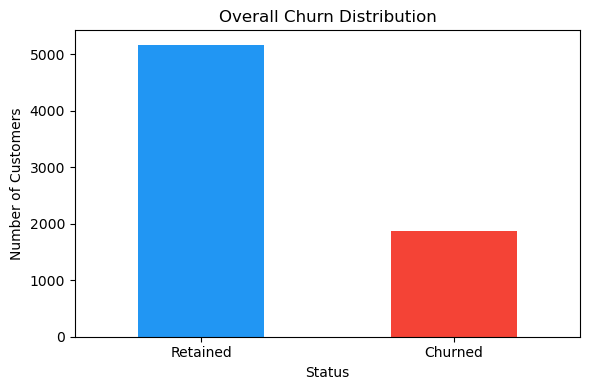

In [38]:
### 8.1 Overall Churn Distribution
plt.figure(figsize=(6, 4))
df['Churn'].map({1: 'Churned', 0: 'Retained'}).value_counts().plot(kind='bar', color=['#2196F3', '#F44336'])
plt.title('Overall Churn Distribution')
plt.xlabel('Status')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

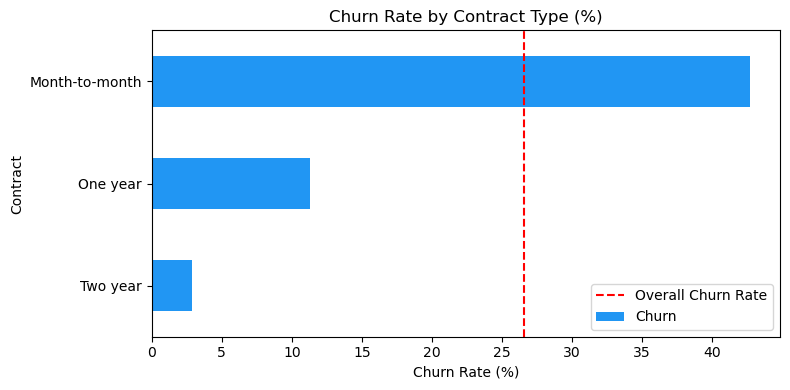

In [39]:
### 8.2 Churn Rate by Contract Type
plt.figure(figsize=(8, 4))
contract_churn.sort_values().plot(kind='barh', color='#2196F3')
plt.title('Churn Rate by Contract Type (%)')
plt.xlabel('Churn Rate (%)')
plt.axvline(x=churn_rate, color='red', linestyle='--', label='Overall Churn Rate')
plt.legend()
plt.tight_layout()
plt.show()

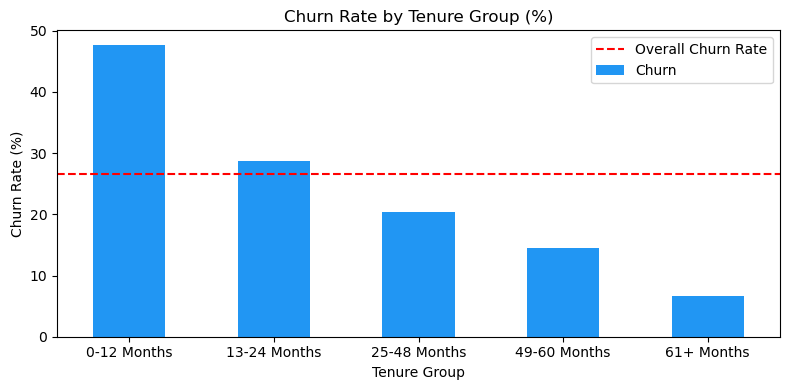

In [40]:
### 8.3 Churn Rate by Tenure Group
plt.figure(figsize=(8, 4))
tenure_order = ['0-12 Months', '13-24 Months', '25-48 Months', '49-60 Months', '61+ Months']
tenure_churn_ordered = tenure_churn.reindex(tenure_order)
tenure_churn_ordered.plot(kind='bar', color='#2196F3')
plt.title('Churn Rate by Tenure Group (%)')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=churn_rate, color='red', linestyle='--', label='Overall Churn Rate')
plt.legend()
plt.tight_layout()
plt.show()

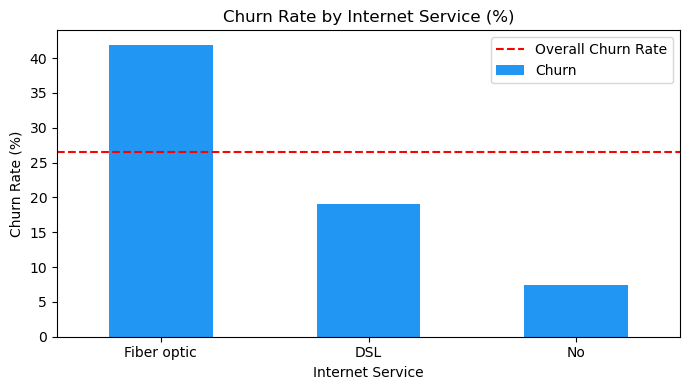

In [41]:
### 8.4 Churn Rate by Internet Service
plt.figure(figsize=(7, 4))
internet_churn.sort_values(ascending=False).plot(kind='bar', color='#2196F3')
plt.title('Churn Rate by Internet Service (%)')
plt.xlabel('Internet Service')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=churn_rate, color='red', linestyle='--', label='Overall Churn Rate')
plt.legend()
plt.tight_layout()
plt.show()

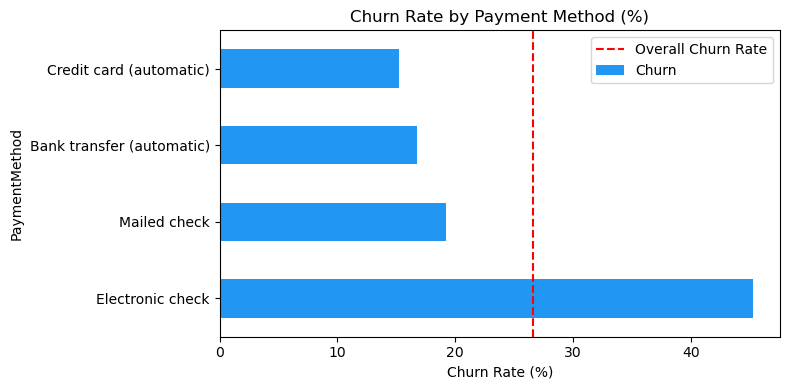

In [42]:
### 8.5 Churn Rate by Payment Method
plt.figure(figsize=(8, 4))
payment_churn.sort_values(ascending=False).plot(kind='barh', color='#2196F3')
plt.title('Churn Rate by Payment Method (%)')
plt.xlabel('Churn Rate (%)')
plt.axvline(x=churn_rate, color='red', linestyle='--', label='Overall Churn Rate')
plt.legend()
plt.tight_layout()
plt.show()

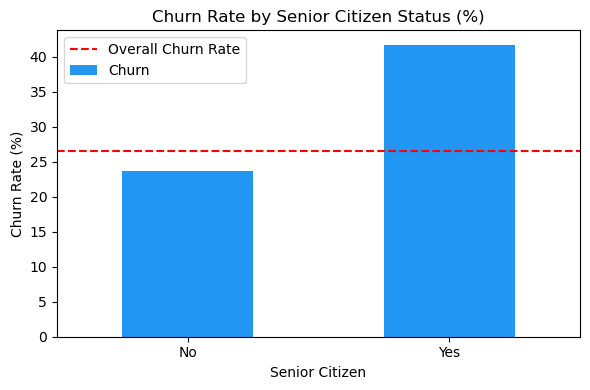

In [43]:
### 8.6 Churn Rate by Senior Citizen
plt.figure(figsize=(6, 4))
senior_churn.plot(kind='bar', color='#2196F3')
plt.title('Churn Rate by Senior Citizen Status (%)')
plt.xlabel('Senior Citizen')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=churn_rate, color='red', linestyle='--', label='Overall Churn Rate')
plt.legend()
plt.tight_layout()
plt.show()

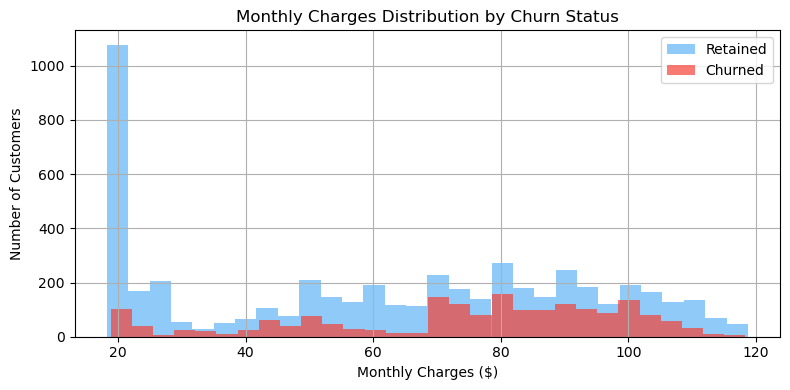

In [45]:
### 8.7 Monthly Charges Distribution by Churn Status
plt.figure(figsize=(8, 4))
df[df['Churn']==0]['MonthlyCharges'].hist(alpha=0.5, label='Retained', bins=30, color='#2196F3')
df[df['Churn']==1]['MonthlyCharges'].hist(alpha=0.7, label='Churned', bins=30, color='#F44336')
plt.title('Monthly Charges Distribution by Churn Status')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

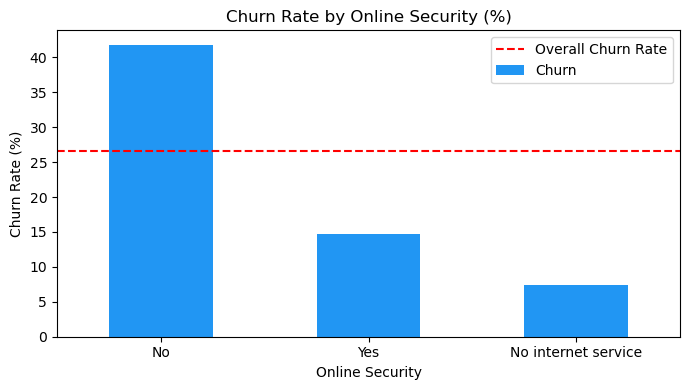

In [46]:
### 8.8 Churn Rate by Online Security
plt.figure(figsize=(7, 4))
security_churn.sort_values(ascending=False).plot(kind='bar', color='#2196F3')
plt.title('Churn Rate by Online Security (%)')
plt.xlabel('Online Security')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.axhline(y=churn_rate, color='red', linestyle='--', label='Overall Churn Rate')
plt.legend()
plt.tight_layout()
plt.show()

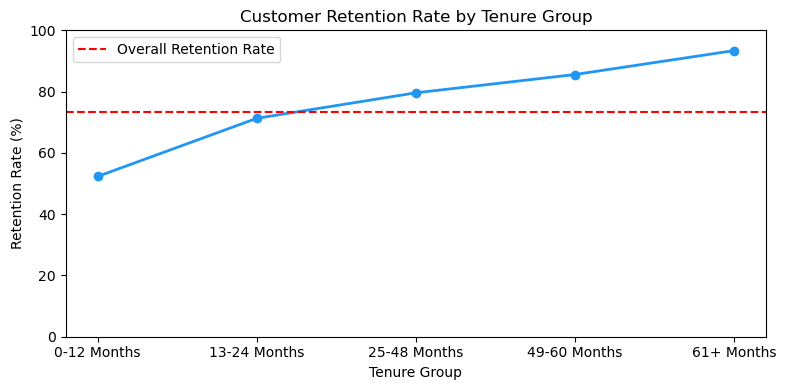

In [47]:
### 8.9 Retention Rate by Tenure Group
tenure_order = ['0-12 Months', '13-24 Months', '25-48 Months', '49-60 Months', '61+ Months']
retention_ordered = tenure_retention['Retention Rate'].reindex(tenure_order)

plt.figure(figsize=(8, 4))
plt.plot(tenure_order, retention_ordered, marker='o', color='#2196F3', linewidth=2)
plt.title('Customer Retention Rate by Tenure Group')
plt.xlabel('Tenure Group')
plt.ylabel('Retention Rate (%)')
plt.ylim(0, 100)
plt.axhline(y=retention_rate, color='red', linestyle='--', label='Overall Retention Rate')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Key Insights & Recommendations

### 9.1 Key Insights

**Churn Overview**
- Overall churn rate is 26.58%, with 1,869 out of 7,032 customers having churned.

**Contract Type — Strongest Churn Predictor**
- Month-to-month customers churn at 42.7% — the highest of all segments
- Two year contract customers churn at only 2.8% — virtually churn-proof
- Contract type appears to be one of the strongest predictors of churn

**Tenure — Early Months are Critical**
- 47.7% of customers in their first 12 months churn
- Churn drops to 6.6% for customers with 61+ months tenure
- Average churned customer leaves after just 18 months

**Internet Service**
- Fiber optic customers churn at 41.9% despite paying premium prices
- Value perception is a major issue for fiber optic customers

**Payment Method**
- Electronic check customers churn at 45.3% — highest of all payment methods
- Automatic payment customers (bank transfer/credit card) churn at 15-17%

**Demographics**
- Senior citizens churn at 41.7% vs 23.7% for non-seniors
- Customers without partners or dependents churn significantly more

**Online Security**
- Customers without online security churn at 41.8%
- Customers with online security churn at only 14.6%
- Customers with online security show substantially higher retention rates than those without it

### 9.2 Recommendations

1. **Incentivize longer contracts** — offer discounts or benefits for 
   customers switching from month-to-month to annual or two-year plans.
   Customers on two-year contracts churn at only 2.8%, compared to 
   42.7% for month-to-month customers.

2. **Focus on the first 12 months** — implement a structured onboarding 
   program targeting new customers. Nearly half (47.7%) of customers 
   churn within their first year.

3. **Promote online security add-ons** — customers with online security 
   churn at 14.6% vs 41.8% without. Actively bundle or discount this 
   feature for new customers.

4. **Investigate fiber optic value** — fiber optic customers pay premium 
   prices but churn at 41.9%. Further investigation into service quality, 
   pricing, and customer expectations is recommended.

5. **Migrate electronic check customers to automatic payments** — 
   electronic check customers churn at 45.3% vs 15-16% for automatic 
   payment customers.

6. **Senior citizen support program** — seniors churn at 41.7% vs 23.7% 
   for non-seniors. Dedicated support and simplified service plans may 
   help improve retention within this segment.

7. **Target single customers with loyalty programs** — customers without 
   partners or dependents exhibit higher churn rates than customers with 
   family connections. Loyalty incentives could improve retention 
   in this segment.

In [48]:
## 10. Export Cleaned Dataset
df.to_csv("../data/telco_churn_cleaned.csv", index=False)
print("Dataset exported successfully!")

Dataset exported successfully!
